# Oil Trade Network 1988-2023

In [1]:
import pandas as pd
df1 = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/TradeData_3_17_2026_11_45_38.csv", encoding='latin-1', index_col=False)
df2 = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/TradeData_3_17_2026_11_47_10.csv", encoding='latin-1', index_col=False)
df3 = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/TradeData_3_17_2026_11_47_47.csv", encoding='latin-1', index_col=False)
df_all = pd.concat([df1, df2, df3])

In [2]:
start_year=1988
end_year=2024
dataframes = {}
imports = {}
exports = {}
all_flows = {}


for year in range(start_year,end_year):
    dataframes[year] = df_all[df_all['refYear'] == year].copy()

In [3]:
for year in range(start_year,end_year):

    imports[year] = dataframes[year][dataframes[year]['flowCode'] == 'M'].copy()
    exports[year] = dataframes[year][dataframes[year]['flowCode'] == 'X'].copy()

    imports[year] = imports[year][['reporterISO', 'partnerISO', 'primaryValue']]
    imports[year].columns = ['source', 'target', 'weight']
    imports[year]['priority'] = 0 

    exports[year] = exports[year][['partnerISO', 'reporterISO', 'primaryValue']]
    exports[year].columns = ['source', 'target', 'weight']
    exports[year]['priority'] = 1  

    all_flows[year] = pd.concat([imports[year], exports[year]])
    
    all_flows[year] = all_flows[year].sort_values('priority')
    all_flows[year] = all_flows[year].drop_duplicates(subset=['source', 'target'], keep='first')
    all_flows[year] = all_flows[year].drop(columns='priority')

In [4]:
# Now turn each year's dataframe into a graph using a new set of dictionaries

import networkx as nx 
trade_graph_dict = {} # digraph

# Nodes which represent broad geographic regions will be removed
node_removal = ['W00', '_X ', 'S19', 'XX ', 'X2 ', 'E19', 'F19','A79', 'O19','X1 ', '_CI', 'A59']

for year in range(start_year,end_year):

    G = nx.from_pandas_edgelist(
        all_flows[year],
        source="source",
        target="target",
        edge_attr="weight",
        create_using=nx.DiGraph()
    )

    G.remove_nodes_from(node_removal)

    trade_graph_dict[year] = G


In [5]:
# A function to prune a graph to the top k partners (#1 country that one imports from)
# The returned graph is directed but UNWEIGHTED

def keep_top_k_neighbors(G, k):
    G_pruned = nx.DiGraph()
    G_pruned.add_nodes_from(G.nodes())
    
    for node in G.nodes():
        # Get all edges from this node with weights
        edges = [(node, neighbor, G[node][neighbor]['weight']) 
                 for neighbor in G.successors(node)]
        
        # Sort by weight descending and take top k
        top_edges = sorted(edges, key=lambda x: x[2], reverse=True)[:k]
        
        # Add to pruned graph
        for u, v, w in top_edges:
            G_pruned.add_edge(u, v)
    
    return G_pruned


In [6]:
pruned_dict = {}

for year in range(start_year, end_year):
    pruned_dict[year] = keep_top_k_neighbors(trade_graph_dict[year], k=1)
    

In [164]:
pruned_dict_k3 = {}

for year in range(start_year, end_year):
    pruned_dict_k3[year] = keep_top_k_neighbors(trade_graph_dict[year], k=3)
    

In [165]:
pruned_trade_graph_k3 = graphdict_to_edgelist(pruned_dict_k3)

In [167]:
pruned_trade_graph_k3.to_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/Oil Trade k3 graph.csv", index=False)

In [168]:
pruned_trade_graph_k3

,source,target,year
0,AUS,IDN,1988
1,AUS,ARE,1988
2,AUS,MYS,1988
3,KOR,OMN,1988
4,KOR,ARE,1988
...,...,...,...
12461,KIR,AUS,2023
12462,NCL,AUS,2023
12463,AIA,DOM,2023
12464,RWA,KEN,2023


In [7]:
def graphdict_to_edgelist(graph_dict):
    
    # Create master dataframe which will contain edges from all years
    dfs = []

    for year, G in graph_dict.items():
        # Create a dataframe out of each year's graph
        df = nx.to_pandas_edgelist(G, edge_key="key")
        # Add the year as a column of that dataframe
        df["year"] = year
        # Append the rows from this dataframe onto the master dataframe containing all years
        dfs.append(df)

    # Now return this master dataframe
    return pd.concat(dfs, ignore_index=True)
    # And write it to a csv file
    #full_pruned_imports_edge_df.to_csv("/Users/kynesantos/Grad School/Trade Networks/Total Trade 2012-2023/importer network.csv", index=False)

In [8]:
pruned_trade_graph = graphdict_to_edgelist(pruned_dict)
pruned_trade_graph

,source,target,year
0,AUS,IDN,1988
1,KOR,OMN,1988
2,PRT,NGA,1988
3,IDN,AUS,1988
4,ITA,CHE,1988
...,...,...,...
5256,KIR,AUS,2023
5257,NCL,AUS,2023
5258,AIA,DOM,2023
5259,RWA,KEN,2023


In [38]:
full_oil_trade_graph = graphdict_to_edgelist(trade_graph_dict)
# full_oil_trade_graph.to_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/Oil Trade full graph.csv", index=False)

In [21]:
#pruned_trade_graph.to_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/Oil Trade k1 graph.csv", index=False)

In [9]:
degree = {}
in_degree = {}
wgt_in_degree = {}
out_degree = {}
con_scores = {}
max_con = {}
min_con = {}
closeness = {}
pageranks = {}
max_pagerank = {}
min_pagerank = {}
clustering = {}
num_nodes = {}
num_edges = {}
num_connectedcomponents = {}
LKL = {}

def weighted_indegree(G):
    return {u: G.in_degree(u, weight='weight') for u in G.nodes()}

def weighted_indegree_centrality(G):
    normalization_factor = sum(weighted_indegree(G).values())
    return {u: (weighted_indegree(G)[u] / normalization_factor) for u in G.nodes }

# for CON score
def con(G,u,v):
    # Inputs:
    # G: a digraph
    # u,v: nodes
    return len(set(G.successors(u)) & set(G.successors(v)))

def con_score(G, u):
    con_u = 0
    for v in G.nodes():
        if u != v:
            con_u += con(G,u,v)
    return con_u

def con_centrality(G):
    return {u: con_score(G, u) for u in G.nodes()}


def safe_average_clustering(G):
    try:
        return nx.average_clustering(G, count_zeros=False)
    except ZeroDivisionError:
        return 0
# A function for computing avg path length on a disconnected unweighted graph

def safe_avgpathlength(G):
    
    components = nx.number_connected_components(G)
    average = 0

    for C in (G.subgraph(c).copy() for c in nx.connected_components(G)):
        print(nx.average_shortest_path_length(C), C.number_of_nodes()) 
        average += (nx.average_shortest_path_length(C)) * (C.number_of_nodes() / G.number_of_nodes())
    
    print("Average = %s" % average)
    return average

# Implementing LKL scores
def LKL_score(G,u,year):

    # Get normalized CON score
    if ((max_con[year] - min_con[year]) > 0):
        con_norm = (con_score(G,u) - min_con[year]) / (max_con[year] - min_con[year])
    else:
        con_norm = 0

    # Get normalized pagerank
    if (max_pagerank[year] - min_pagerank[year] > 0): 
        pagerank_norm = (pageranks[year][u] - min_pagerank[year]) / (max_pagerank[year] - min_pagerank[year])
    else:
        pagerank_norm = 0
        
    return con_norm - pagerank_norm


def LKL_centrality(G, year):
    return {u: LKL_score(G, u, year) for u in G.nodes()}

# This function makes a stat table given a graph dictionary and index range
def stat_table_maker(graph_dict, startyear, endyear):

    for year in range(startyear, endyear):
        degree[year] = nx.degree_centrality(graph_dict[year])
        in_degree[year] = nx.in_degree_centrality(graph_dict[year])
        wgt_in_degree[year] = weighted_indegree_centrality(graph_dict[year])
        out_degree[year] = nx.out_degree_centrality(graph_dict[year])
        con_scores[year] = con_centrality(graph_dict[year])
        closeness[year] = nx.closeness_centrality(graph_dict[year])
        max_con[year] = max(con_scores[year].values()) if con_scores[year] else None
        min_con[year] = min(con_scores[year].values()) if con_scores[year] else None
        pageranks[year] = nx.pagerank(graph_dict[year])
        max_pagerank[year] = max(pageranks[year].values()) if pageranks[year] else None
        min_pagerank[year] = min(pageranks[year].values()) if pageranks[year] else None
        LKL[year] = LKL_centrality(graph_dict[year], year)
    
        centrality_maps = {
        "pagerank": pageranks,
        "degree": degree,
        "in degree": in_degree,
        "weighted in degree": wgt_in_degree,
        "out degree": out_degree,
        "con": con_scores,
        "closeness": closeness,
        "LKL": LKL,
        "degree different": degree_difference
        }

    rows = {}

    for name, yearly_scores in centrality_maps.items():
        rows[name] = {
            year: [k for k, _ in sorted(scores.items(),
                                   key=lambda x: x[1],
                                   reverse=True)[:5]] if scores else None
        for year, scores in yearly_scores.items()
        }

    # add a row for clustering values
    rows['clustering'] = {
        year: clustering.get(year, None)  # default to None if missing
        for year in range(startyear, endyear)
    }

    rows['# nodes'] = {year: graph_dict[year].number_of_nodes() for year in range(startyear, endyear)}
    rows['# edges'] = {year: graph_dict[year].number_of_edges() for year in range(startyear, endyear)}
    rows['# of connected components'] = {year: nx.number_connected_components(graph_dict[year].to_undirected()) for year in range(startyear, endyear)}
    rows['Average path length'] = {year: safe_avgpathlength(graph_dict[year].to_undirected()) for year in range(startyear, endyear)}

    stat_table = pd.DataFrame(rows).T.sort_index(axis=1)

    return stat_table


In [10]:
# How does a country's ranking differ when comparing its weighted in degree in the full trade graph (importance in absolute trade volume) 
# versus its indegree in the pruned trade graph (importance as a top import source) ?

degree_difference = {}
indegree_pruned = {}
wgtindegree_trade = {}

for year in range(2000, 2024):
    indegree_pruned[year] = nx.in_degree_centrality(pruned_dict[year])
    wgtindegree_trade[year] = weighted_indegree_centrality(trade_graph_dict[year])
    degree_difference[year] = {k: indegree_pruned[year][k] - wgtindegree_trade[year][k] for k in indegree_pruned[year]}



In [11]:
oil_stats = stat_table_maker(trade_graph_dict, start_year, end_year)

2.431638418079096 60
Average = 2.431638418079096
2.45981981981982 75
Average = 2.45981981981982
2.5025991792065665 86
0 1
Average = 2.4738336713995945
2.482051282051282 105
Average = 2.482051282051282
2.5312407898614797 117
0 1
Average = 2.5097895967270603
2.6606791338582676 128
1.0 2
0 1
Average = 2.615014726212658
2.601138565891473 129
0 1
0 1
0 1
0 1
1.0 2
Average = 2.500347222222222
2.5296174208370794 142
0 1
0 1
0 1
0 1
Average = 2.4603128339648306
2.4648086915446386 146
0 1
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.3520396664412893
2.5267162944582298 156
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.388895405669599
2.501298701298701 155
0 1
0 1
Average = 2.469435023575151
2.443907675791734 162
0 1
1.0 2
0 1
0 1
Average = 2.382712835199167
2.5376310338334065 179
0 1
Average = 2.523533083645443
2.4966933518969716 170
Average = 2.4966933518969716
2.471192682347351 184
Average = 2.471192682347351
2.47298927188472 178
Average = 2.47298927188472
2.5330838679021146 184
Average = 2.533083867

In [27]:
# oil_stats.to_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/Oil Trade stats.csv")

In [28]:
pruned_dict

{1988: <networkx.classes.digraph.DiGraph at 0x14ed2ec10>,
 1989: <networkx.classes.digraph.DiGraph at 0x14fee9a50>,
 1990: <networkx.classes.digraph.DiGraph at 0x14feee010>,
 1991: <networkx.classes.digraph.DiGraph at 0x14fef2f90>,
 1992: <networkx.classes.digraph.DiGraph at 0x14fef9890>,
 1993: <networkx.classes.digraph.DiGraph at 0x14ff04810>,
 1994: <networkx.classes.digraph.DiGraph at 0x14ff104d0>,
 1995: <networkx.classes.digraph.DiGraph at 0x14ff1c610>,
 1996: <networkx.classes.digraph.DiGraph at 0x14ff25590>,
 1997: <networkx.classes.digraph.DiGraph at 0x14ff328d0>,
 1998: <networkx.classes.digraph.DiGraph at 0x14ff4c890>,
 1999: <networkx.classes.digraph.DiGraph at 0x14ff56150>,
 2000: <networkx.classes.digraph.DiGraph at 0x14ff6c610>,
 2001: <networkx.classes.digraph.DiGraph at 0x14ff7b8d0>,
 2002: <networkx.classes.digraph.DiGraph at 0x14ff8e4d0>,
 2003: <networkx.classes.digraph.DiGraph at 0x14ff9dd10>,
 2004: <networkx.classes.digraph.DiGraph at 0x14ffb4e50>,
 2005: <networ

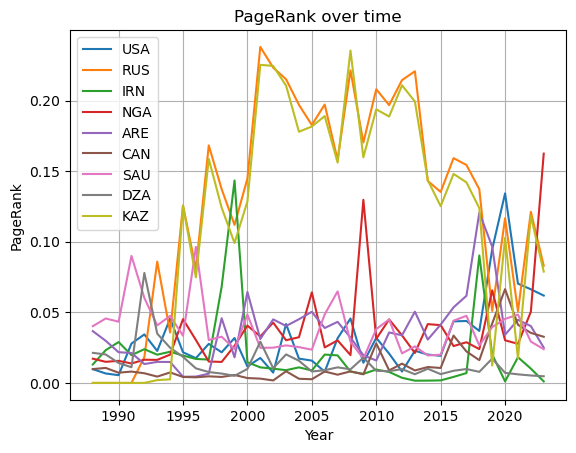

In [12]:
import matplotlib.pyplot as plt

pagerank_countries = ["USA", "RUS", "IRN", "NGA", "ARE", "CAN", "SAU", "DZA", "KAZ"]
years = [i for i in range(start_year,end_year)]

data = {c: [pageranks[year].get(c, 0.0) for year in years] for c in pagerank_countries}

for c in pagerank_countries:
    plt.plot(years, data[c], label=c)

plt.xlabel("Year")
plt.ylabel("PageRank")
plt.title("PageRank over time")
plt.legend()
plt.grid(True)
plt.show()

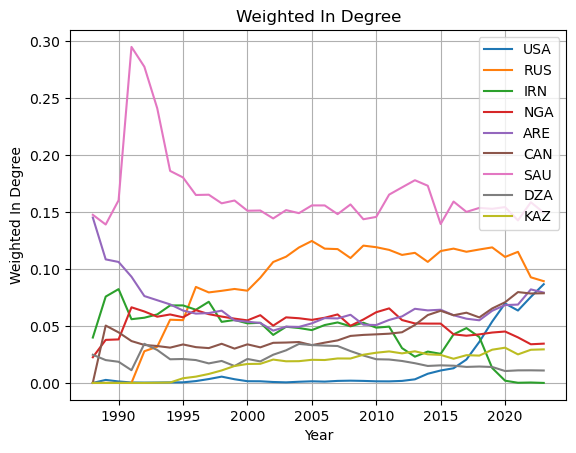

In [13]:
WID_countries = ["USA", "RUS", "IRN", "NGA", "ARE", "CAN", "SAU", "DZA", "KAZ"]
years = [i for i in range(start_year,end_year)]

data = {c: [wgt_in_degree[year].get(c, 0.0) for year in years] for c in WID_countries}

for c in WID_countries:
    plt.plot(years, data[c], label=c)

plt.xlabel("Year")
plt.ylabel("Weighted In Degree")
plt.title("Weighted In Degree")
plt.legend()
plt.grid(True)
plt.show()

# Computing Spearman Correlations of how Rankings differ by year

How much does the oil trade hierarchy reshuffle year after year?

In [14]:
pagerank_df = pd.DataFrame.from_dict(pageranks)
wgt_in_degree_df =  pd.DataFrame.from_dict(wgt_in_degree)
wid_matrix = wgt_in_degree_df.corr(method='spearman')
pagerank_matrix = pagerank_df.corr(method='spearman')



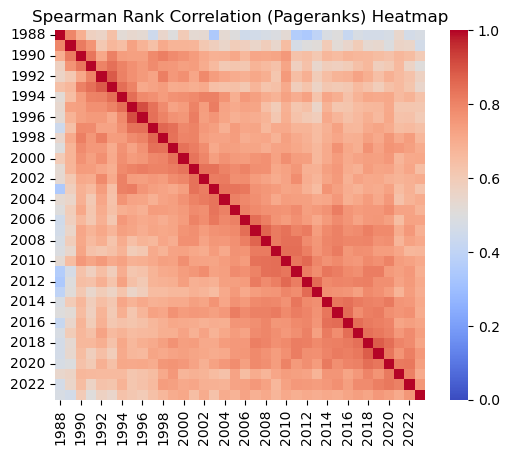

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pagerank_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Pageranks) Heatmap")
plt.show()

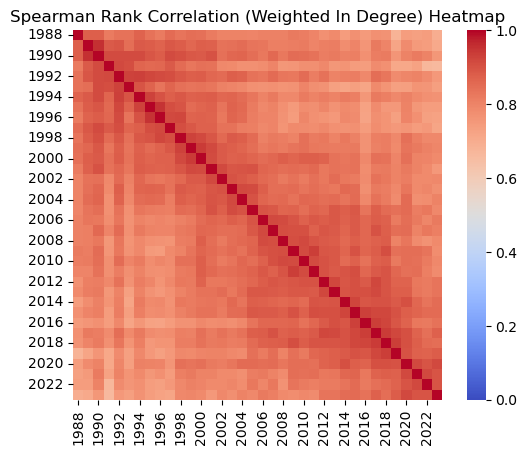

In [16]:
sns.heatmap(wid_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Weighted In Degree) Heatmap")
plt.show()

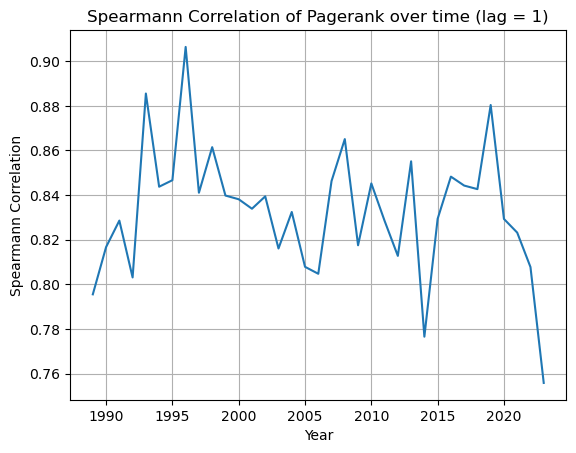

In [94]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_pagerank = [pagerank_matrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_pagerank)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Pagerank over time (lag = {lag})")
plt.grid(True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


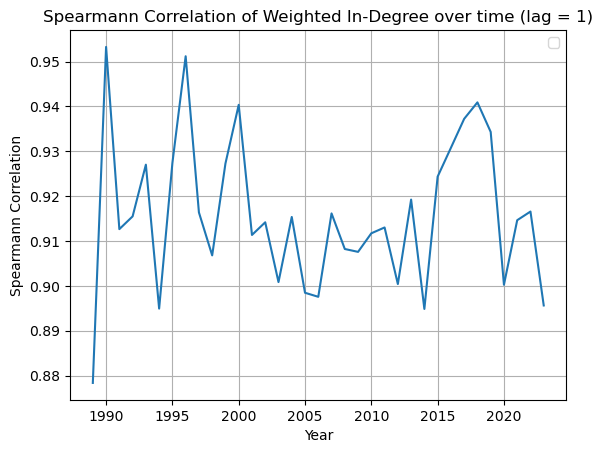

In [95]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_wid = [wid_matrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_wid)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Weighted In-Degree over time (lag = {lag})")
plt.legend()
plt.grid(True)
plt.show()

## Taking only the top 20 players
To exclude noise from smaller countries, let's only consider the top 20 players (determined by total weighted in degree, so total oil exports from all years)

In [17]:
top20exporters = ['SAU', 'RUS', 'IRQ', 'ARE', 'CAN', 'NGA', 'KWT', 'AGO', 'VEN', 'NOR', 
                    'IRN', 'MEX', 'LBY', 'KAZ','QAT', 'GBR', 'USA', 'DZA', 'BRA', 'NLD']
top20pagerank = ['RUS', 'KAZ', 'NGA', 'GAB', 'USA', 'COG', 'SAU', 'KWT', 'EGY', 'NLD', 
                    'VEN', 'DZA', 'ARE', 'ECU','IRN', 'NOR', 'COL', 'CAN', 'IRQ', 'GBR']


top20pagerank_df = pagerank_df.loc[top20pagerank].copy()
top20wid_df = wgt_in_degree_df.loc[top20exporters].copy()

top20pagerankmatrix  = top20pagerank_df.corr(method='spearman')
top20WIDmatrix  = top20wid_df.corr(method='spearman')



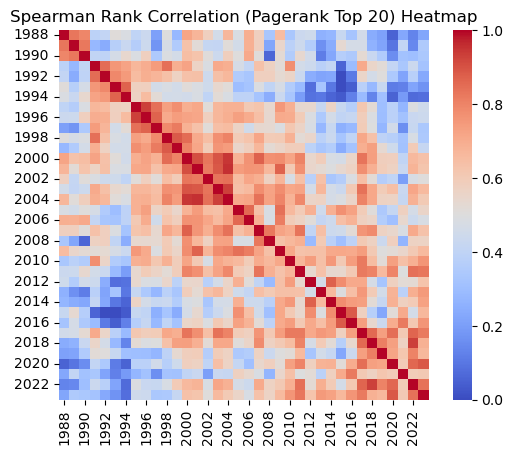

In [18]:
sns.heatmap(top20pagerankmatrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Pagerank Top 20) Heatmap")
plt.show()

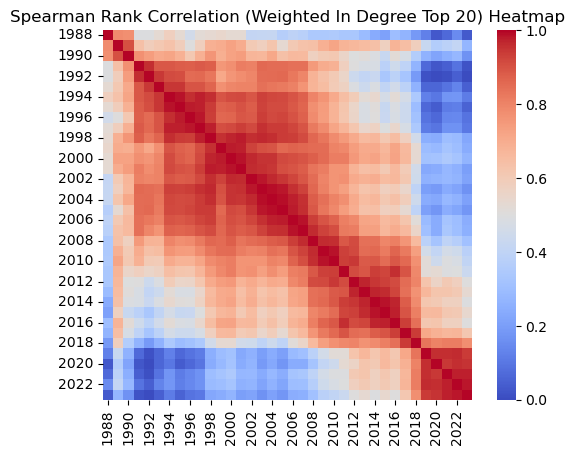

In [19]:
sns.heatmap(top20WIDmatrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Weighted In Degree Top 20) Heatmap")
plt.show()

In [20]:
top20pagerankmatrix[1998][2000]

0.849624060150376

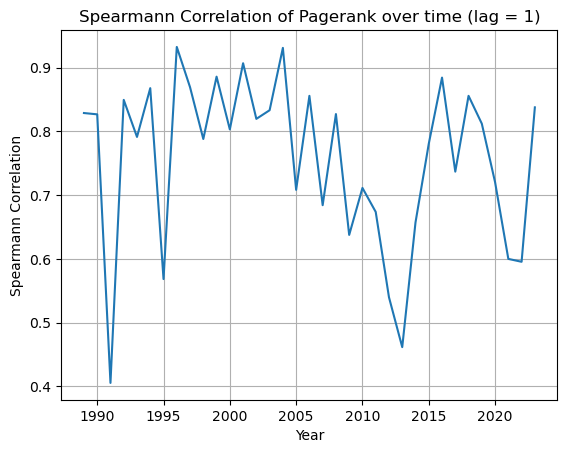

In [21]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_pagerank = [top20pagerankmatrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_pagerank)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Pagerank over time (lag = {lag})")
plt.grid(True)
plt.show()

The range of values here varies much more widely than it does for weighted in-degree does: the ranking of actual top exporters does not change much

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


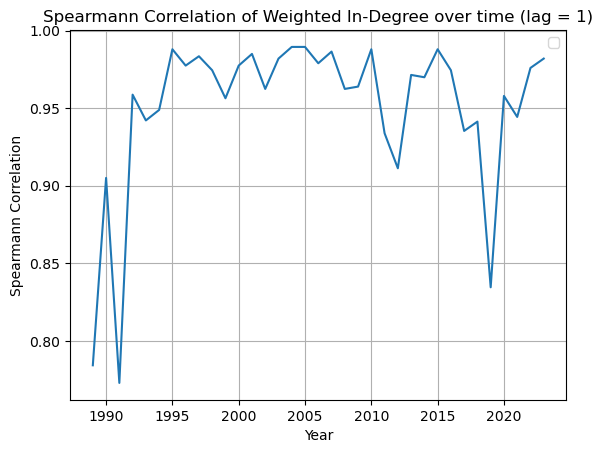

In [22]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_wid = [top20WIDmatrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_wid)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Weighted In-Degree over time (lag = {lag})")
plt.grid(True)
plt.show()

# Closeness and Betweenness

In [23]:
betweenness = {}
for year in range(start_year, end_year):
        closeness[year] = nx.closeness_centrality(trade_graph_dict[year])
        betweenness[year] = nx.betweenness_centrality(trade_graph_dict[year])


In [24]:
top20closeness = ['USA', 'NLD', 'GBR', 'FRA', 'ARE', 'CHN', 'DEU', 'ITA', 'BEL', 'IND', 
                  'ESP', 'CAN', 'KOR', 'SGP', 'ZAF', 'NGA', 'RUS', 'JPN', 'CHE', 'SWE']
top20btwn = ['USA', 'NLD', 'ARE', 'CHN', 'FRA', 'ZAF', 'NGA', 'RUS', 'SGP', 'DEU', 
                  'GBR', 'IND', 'KOR', 'CAN', 'ROU', 'ESP', 'AUS', 'THA', 'ITA', 'DZA']

closeness_df = pd.DataFrame.from_dict(closeness)
top20closeness_df = closeness_df.loc[top20closeness].copy()
closeness_matrix = closeness_df.corr(method='spearman')
top20closeness_matrix = top20closeness_df.corr(method='spearman')

betweenness_df = pd.DataFrame.from_dict(betweenness)
top20betweenness_df = betweenness_df.loc[top20btwn].copy()
btwnness_matrix = betweenness_df.corr(method='spearman')
top20btwn_matrix = top20betweenness_df.corr(method='spearman')


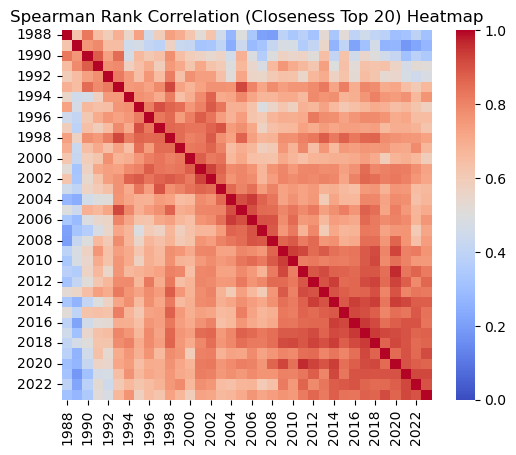

In [25]:
sns.heatmap(top20closeness_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Closeness Top 20) Heatmap")
plt.show()

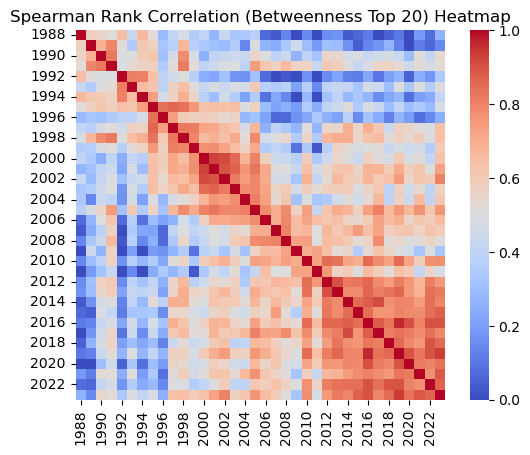

In [26]:
sns.heatmap(top20btwn_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (Betweenness Top 20) Heatmap")
plt.show()

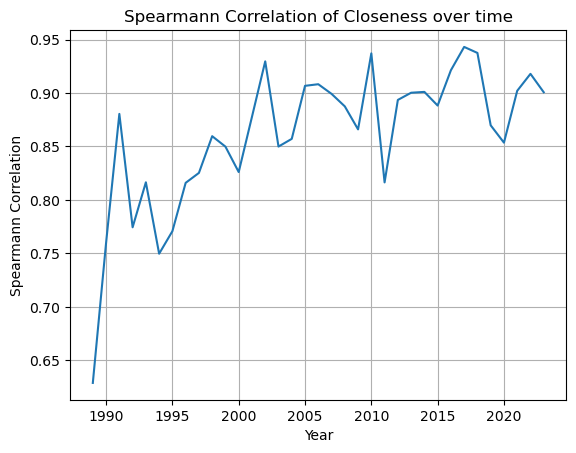

In [30]:
years = [i for i in range(start_year+lag, end_year)]

data_closeness = [top20closeness_matrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_closeness)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Closeness over time")
plt.grid(True)
plt.show()

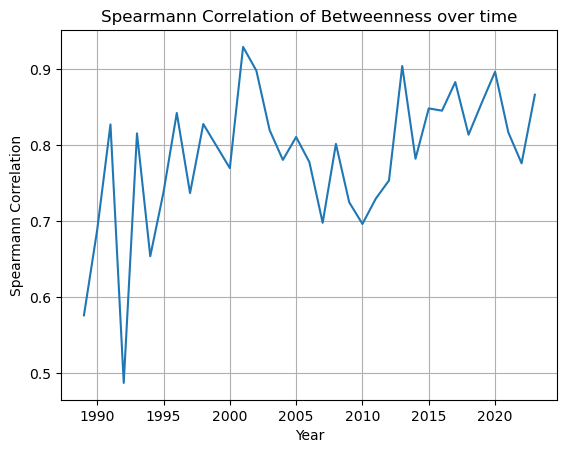

In [31]:
years = [i for i in range(start_year+lag, end_year)]

data_btwn = [top20btwn_matrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_btwn)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of Betweenness over time")
plt.grid(True)
plt.show()

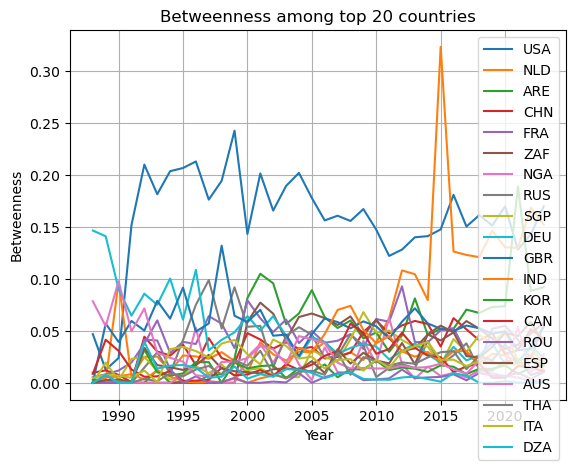

In [39]:
years = [i for i in range(start_year,end_year)]

data_btwn_countryview = {c: [betweenness[year].get(c, 0.0) for year in years] for c in top20btwn}

for c in top20btwn:
    plt.plot(years, data_btwn_countryview[c], label=c)

plt.xlabel("Year")
plt.ylabel("Betweenness")
plt.title("Betweenness among top 20 countries")
plt.legend()
plt.grid(True)
plt.show()

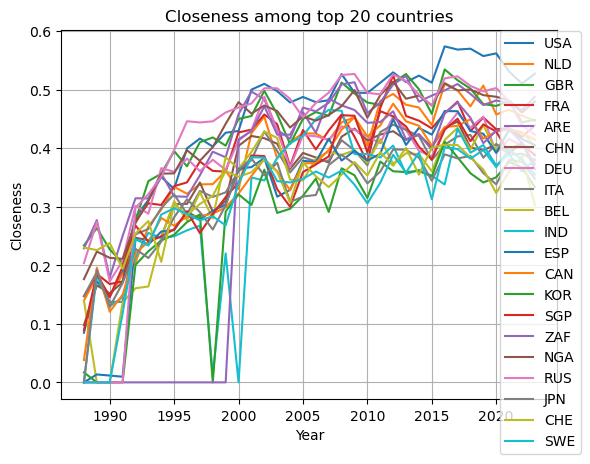

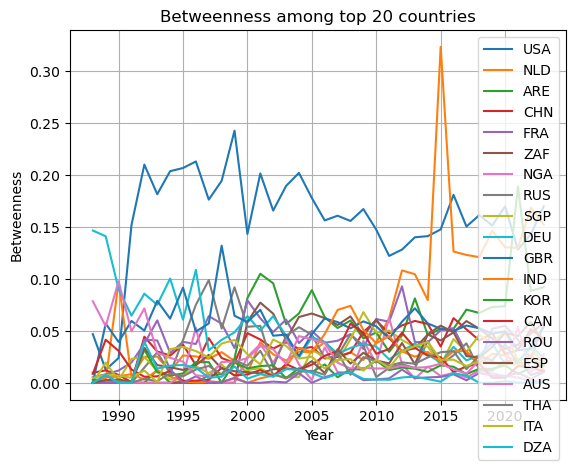

In [49]:
data_close_countryview = {c: [closeness[year].get(c, 0.0) for year in years] for c in top20closeness}

for c in top20closeness:
    plt.plot(years, data_close_countryview[c], label=c)

plt.xlabel("Year")
plt.ylabel("Closeness")
plt.title("Closeness among top 20 countries")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right', borderaxespad=0.1)
plt.grid(True)
plt.show()

years = [i for i in range(start_year,end_year)]

data_btwn_countryview = {c: [betweenness[year].get(c, 0.0) for year in years] for c in top20btwn}

for c in top20btwn:
    plt.plot(years, data_btwn_countryview[c], label=c)

plt.xlabel("Year")
plt.ylabel("Betweenness")
plt.title("Betweenness among top 20 countries")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
betweenness[year].get('NLD', 0.0)

0.15208941167684029

# Community Structure

How much is the oil trade graph organized into communities? (Using the Louvain Algorithm)

In [114]:
def louvain_communities(
    G, weight="weight", resolution=1, threshold=0.0000001, max_level=None, seed=None
):
    r"""Find the best partition of a graph using the Louvain Community Detection
    Algorithm.

    Louvain Community Detection Algorithm is a simple method to extract the community
    structure of a network. This is a heuristic method based on modularity optimization. [1]_

    The algorithm works in 2 steps. On the first step it assigns every node to be
    in its own community and then for each node it tries to find the maximum positive
    modularity gain by moving each node to all of its neighbor communities. If no positive
    gain is achieved the node remains in its original community.

    The modularity gain obtained by moving an isolated node $i$ into a community $C$ can
    easily be calculated by the following formula (combining [1]_ [2]_ and some algebra):

    .. math::
        \Delta Q = \frac{k_{i,in}}{2m} - \gamma\frac{ \Sigma_{tot} \cdot k_i}{2m^2}

    where $m$ is the size of the graph, $k_{i,in}$ is the sum of the weights of the links
    from $i$ to nodes in $C$, $k_i$ is the sum of the weights of the links incident to node $i$,
    $\Sigma_{tot}$ is the sum of the weights of the links incident to nodes in $C$ and $\gamma$
    is the resolution parameter.

    For the directed case the modularity gain can be computed using this formula according to [3]_

    .. math::
        \Delta Q = \frac{k_{i,in}}{m}
        - \gamma\frac{k_i^{out} \cdot\Sigma_{tot}^{in} + k_i^{in} \cdot \Sigma_{tot}^{out}}{m^2}

    where $k_i^{out}$, $k_i^{in}$ are the outer and inner weighted degrees of node $i$ and
    $\Sigma_{tot}^{in}$, $\Sigma_{tot}^{out}$ are the sum of in-going and out-going links incident
    to nodes in $C$.

    The first phase continues until no individual move can improve the modularity.

    The second phase consists in building a new network whose nodes are now the communities
    found in the first phase. To do so, the weights of the links between the new nodes are given by
    the sum of the weight of the links between nodes in the corresponding two communities. Once this
    phase is complete it is possible to reapply the first phase creating bigger communities with
    increased modularity.

    The above two phases are executed until no modularity gain is achieved (or is less than
    the `threshold`, or until `max_levels` is reached).

    Be careful with self-loops in the input graph. These are treated as
    previously reduced communities -- as if the process had been started
    in the middle of the algorithm. Large self-loop edge weights thus
    represent strong communities and in practice may be hard to add
    other nodes to.  If your input graph edge weights for self-loops
    do not represent already reduced communities you may want to remove
    the self-loops before inputting that graph.

    Parameters
    ----------
    G : NetworkX graph
    weight : string or None, optional (default="weight")
        The name of an edge attribute that holds the numerical value
        used as a weight. If None then each edge has weight 1.
    resolution : float, optional (default=1)
        If resolution is less than 1, the algorithm favors larger communities.
        Greater than 1 favors smaller communities
    threshold : float, optional (default=0.0000001)
        Modularity gain threshold for each level. If the gain of modularity
        between 2 levels of the algorithm is less than the given threshold
        then the algorithm stops and returns the resulting communities.
    max_level : int or None, optional (default=None)
        The maximum number of levels (steps of the algorithm) to compute.
        Must be a positive integer or None. If None, then there is no max
        level and the threshold parameter determines the stopping condition.
    seed : integer, random_state, or None (default)
        Indicator of random number generation state.
        See :ref:`Randomness<randomness>`.

    Returns
    -------
    list
        A list of sets (partition of `G`). Each set represents one community and contains
        all the nodes that constitute it.

    Examples
    --------
    >>> import networkx as nx
    >>> G = nx.petersen_graph()
    >>> nx.community.louvain_communities(G, seed=123)
    [{0, 4, 5, 7, 9}, {1, 2, 3, 6, 8}]

    Notes
    -----
    The order in which the nodes are considered can affect the final output. In the algorithm
    the ordering happens using a random shuffle.

    References
    ----------
    .. [1] Blondel, V.D. et al. Fast unfolding of communities in
       large networks. J. Stat. Mech 10008, 1-12(2008). https://doi.org/10.1088/1742-5468/2008/10/P10008
    .. [2] Traag, V.A., Waltman, L. & van Eck, N.J. From Louvain to Leiden: guaranteeing
       well-connected communities. Sci Rep 9, 5233 (2019). https://doi.org/10.1038/s41598-019-41695-z
    .. [3] Nicolas Dugué, Anthony Perez. Directed Louvain : maximizing modularity in directed networks.
        [Research Report] Université d’Orléans. 2015. hal-01231784. https://hal.archives-ouvertes.fr/hal-01231784

    See Also
    --------
    louvain_partitions
    :any:`leiden_communities`
    """

    partitions = louvain_partitions(G, weight, resolution, threshold, seed)
    if max_level is not None:
        if max_level <= 0:
            raise ValueError("max_level argument must be a positive integer or None")
        partitions = itertools.islice(partitions, max_level)
    final_partition = deque(partitions, maxlen=1)
    return final_partition.pop()

In [160]:
communities = {}
partitions = {}
num_communities = {}
modularity = {}

for year in range(start_year, end_year):
    communities[year] = nx.community.louvain_communities(trade_graph_dict[year], weight="weight")
    partitions[year] = nx.community.louvain_partitions(trade_graph_dict[year], weight="weight")
    num_communities[year] = len(communities[year])
    modularity[year] = nx.community.modularity(trade_graph_dict[year],  communities[year], weight="weight")
    

In [161]:
modularity[2020]

0.33686285695569107

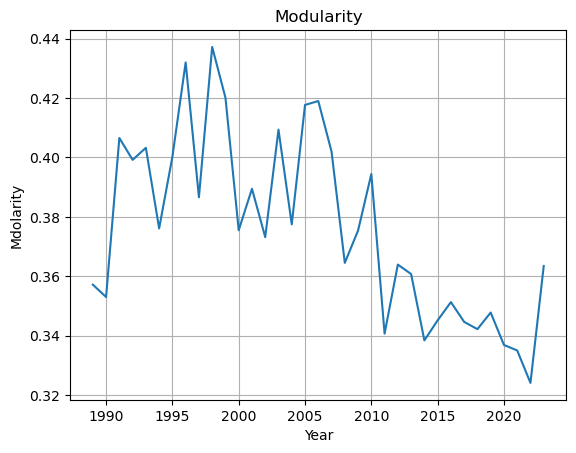

In [162]:
lag = 1 # space between years we want to compare

years = [i for i in range(start_year+lag, end_year)]

data_modularity = [modularity[i] for i in years]

plt.plot(years, data_modularity)

plt.xlabel("Year")
plt.ylabel("Mdolarity")
plt.title(f"Modularity")
plt.grid(True)
plt.show()

In [124]:
for community in communities[2010]:
    print(community)

{'OMN', 'YEM', 'GNB', 'ERI', 'COG', 'CHN', 'RWA', 'MNG', 'COD', 'SDN', 'PRT', 'IRN', 'MKD', 'AGO', 'GRC', 'SSD', 'IRQ'}
{'SWE', 'HRV', 'BIH', 'DEU', 'BLR', 'SVK', 'UKR', 'MNE', 'FIN', 'RUS', 'SRB', 'BGR', 'POL', 'HUN', 'CZE', 'LTU', 'GEO'}
{'ISL', 'IRL', 'GIB', 'DNK', 'NOR', 'GBR', 'DZA', 'GRL', 'GNQ'}
{'LUX', 'BEL', 'GUM', 'NLD'}
{'ZWE', 'GMB', 'SEN', 'MLT', 'CUB', 'CHL', 'MDG', 'CPV', 'URY', 'ESP', 'SHN', 'GHA', 'CIV', 'MLI', 'ZAF', 'LVA', 'NGA', 'BES', 'BRA', 'PRY', 'CMR', 'BEN', 'LSO', 'SWZ', 'BWA', 'MWI', 'EST', 'SVN', 'NAM', 'LCA', 'ATA', 'MOZ', 'LBR', 'ETH'}
{'TJK', 'NER', 'AFG', 'AUT', 'FRA', 'KGZ', 'MDA', 'UZB', 'TUR', 'ROU', 'KAZ', 'BMU'}
{'GIN', 'JOR', 'LAO', 'MAR', 'BHR', 'LKA', 'ZMB', 'PAK', 'TZA', 'KWT', 'ARE', 'UGA', 'SGP', 'MMR', 'SAU', 'KHM', 'IDN', 'SOM', 'PSE', 'WSM', 'JPN', 'NPL', 'MUS', 'PHL', 'IND', 'BGD', 'MDV', 'THA', 'AND', 'TLS', 'BRN', 'KOR', 'SLB', 'QAT', 'SYR'}
{'TGO', 'EGY', 'TUN', 'CYP', 'AZE', 'ITA', 'TKM', 'LBY', 'ALB', 'CHE', 'ISR'}
{'SYC', 'CAN', 'BHS

# CON Scores    

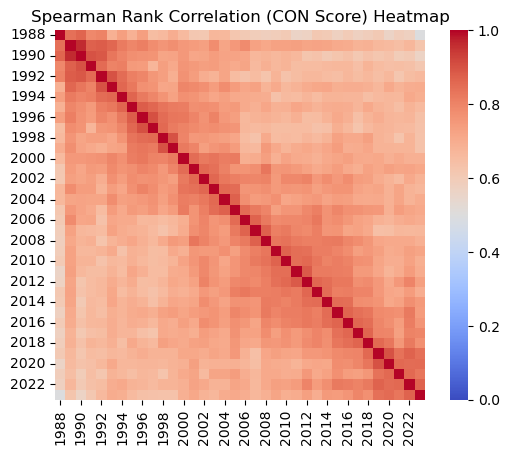

In [51]:
conscore_df = pd.DataFrame.from_dict(con_scores)
conscore_matrix = conscore_df.corr(method='spearman')

sns.heatmap(conscore_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (CON Score) Heatmap")
plt.show()

In [63]:
# Redo with only the top 20 contenders
top_20CON = (
    conscore_df
    .sum(axis=1, skipna=True)
    .sort_values(ascending=False)
    .head(10)
)
top20CON = list(top_20CON.keys())
top20CON

['USA',
 'NLD',
 'FRA',
 'CHN',
 'ESP',
 'DEU',
 'KOR',
 'SGP',
 'CAN',
 'GBR',
 'ITA',
 'IND',
 'JPN',
 'THA',
 'BEL',
 'PRT',
 'SWE',
 'MYS',
 'AUS',
 'GRC']

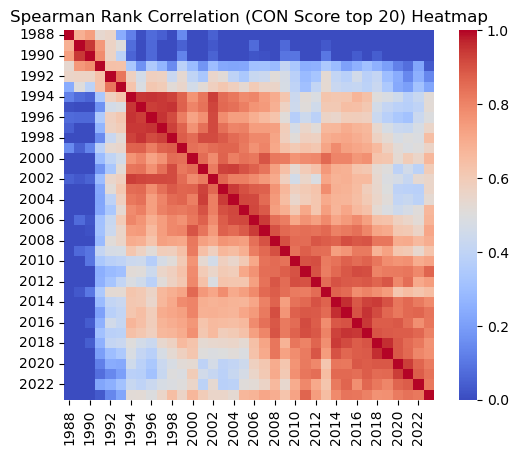

In [67]:
top20con_df = conscore_df.loc[top20CON].copy()
top20conscore_matrix = top20con_df.corr(method='spearman')

sns.heatmap(top20conscore_matrix, vmin=0, vmax=1, cmap='coolwarm', square=True)

plt.title("Spearman Rank Correlation (CON Score top 20) Heatmap")
plt.show()

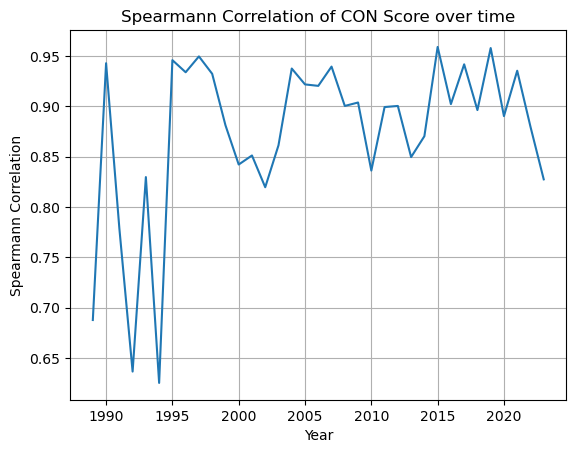

In [68]:
years = [i for i in range(start_year+lag, end_year)]

data_con = [top20conscore_matrix[i-lag][i] for i in range(start_year+lag, end_year)]

plt.plot(years, data_con)

plt.xlabel("Year")
plt.ylabel("Spearmann Correlation")
plt.title(f"Spearmann Correlation of CON Score over time")
plt.grid(True)
plt.show()

# Import Oil Price Data

In [150]:
oil_prices = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/Oil/PET_PRI_SPT_S1_A.csv", index_col=False)
oil_prices = oil_prices[['Year', 'Cushing, OK WTI Spot Price FOB (Dollars per Barrel)']]
oil_prices.columns = ['Year', 'Price']
oil_prices = oil_prices[(oil_prices['Year'] >= start_year) & (oil_prices['Year'] <= end_year-1) ].copy()
oil_prices

,Year,Price
2,1988.0,15.97
3,1989.0,19.64
4,1990.0,24.53
5,1991.0,21.54
6,1992.0,20.58
7,1993.0,18.43
8,1994.0,17.20
9,1995.0,18.43
10,1996.0,22.12
11,1997.0,20.61


In [111]:
CPI_df = pd.read_csv("/Users/kynesantos/Grad School/Trade Networks/CPIAUCSL (2).csv", index_col=False)
CPI_df.columns = ['Year', 'CPI']
CPI_df["Year"] = pd.to_datetime(CPI_df["Year"]).dt.year
CPI_df

,Year,CPI
0,1987,113.617
1,1988,118.275
2,1989,123.942
3,1990,130.658
4,1991,136.167
5,1992,140.308
6,1993,144.475
7,1994,148.225
8,1995,152.383
9,1996,156.858


In [112]:
# Turn dataframes into dictionaries

oil_prices_dict = oil_prices.set_index("Year")["Price"].to_dict()
CPI_dict = CPI_df.set_index("Year")["CPI"].to_dict()

In [117]:
oil_prices_dict

{1986.0: 15.05,
 1987.0: 19.2,
 1988.0: 15.97,
 1989.0: 19.64,
 1990.0: 24.53,
 1991.0: 21.54,
 1992.0: 20.58,
 1993.0: 18.43,
 1994.0: 17.2,
 1995.0: 18.43,
 1996.0: 22.12,
 1997.0: 20.61,
 1998.0: 14.42,
 1999.0: 19.34,
 2000.0: 30.38,
 2001.0: 25.98,
 2002.0: 26.18,
 2003.0: 31.08,
 2004.0: 41.51,
 2005.0: 56.64,
 2006.0: 66.05,
 2007.0: 72.34,
 2008.0: 99.67,
 2009.0: 61.95,
 2010.0: 79.48,
 2011.0: 94.88,
 2012.0: 94.05,
 2013.0: 97.98,
 2014.0: 93.17,
 2015.0: 48.66,
 2016.0: 43.29,
 2017.0: 50.8,
 2018.0: 65.23,
 2019.0: 56.99,
 2020.0: 39.16,
 2021.0: 68.13,
 2022.0: 94.9,
 2023.0: 77.58,
 2024.0: 76.63,
 2025.0: 65.39,
 nan: nan}

In [114]:
# Make dictionary of adjusted oil prices
adjusted_oilprices = {}

for year in range(start_year, end_year):
    inflation_factor = CPI_dict[end_year] / CPI_dict[year]
    adjusted_oilprices[year] = oil_prices_dict[year] * inflation_factor



In [116]:
adjusted_oilprices

{1988: 42.356855294863664,
 1989: 49.708966452050156,
 1990: 58.89430375484089,
 1991: 49.623292868316106,
 1992: 46.01237876671323,
 1993: 40.01698660667935,
 1994: 36.40145454545454,
 1995: 37.94028297119757,
 1996: 44.23746165321501,
 1997: 40.27606777760473,
 1998: 27.750326118963482,
 1999: 36.41979865892678,
 2000: 55.34603953726072,
 2001: 46.0335628833836,
 2002: 45.659368533416355,
 2003: 52.98768391304347,
 2004: 68.930929235395,
 2005: 90.99261380571218,
 2006: 102.79796832673473,
 2007: 109.445719770044,
 2008: 145.2529553922343,
 2009: 90.57204623307622,
 2010: 114.33040334562263,
 2011: 132.3282467333265,
 2012: 128.5065156411976,
 2013: 131.94190236615268,
 2014: 123.47017578100247,
 2015: 64.40681800153584,
 2016: 56.58209795629257,
 2017: 65.01221192798657,
 2018: 81.49151947431302,
 2019: 69.9293535378032,
 2020: 47.45655375961925,
 2021: 78.87222985315879,
 2022: 101.73374956429026,
 2023: 79.87020423166165}

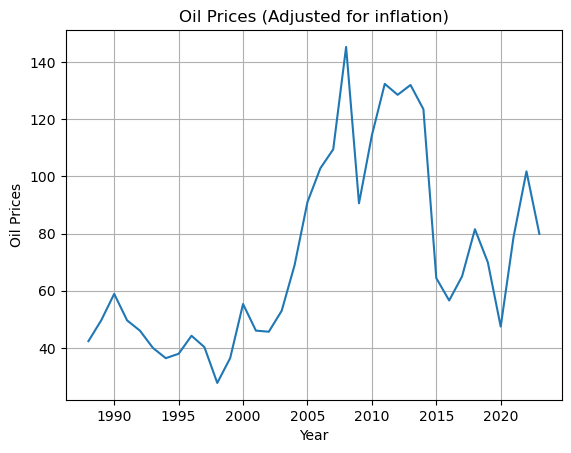

In [115]:
years = [i for i in range(start_year, end_year)]

data_oil = [adjusted_oilprices[i] for i in range(start_year, end_year)]

plt.plot(years, data_oil)

plt.xlabel("Year")
plt.ylabel("Oil Prices")
plt.title(f"Oil Prices (Adjusted for inflation)")
plt.grid(True)
plt.show()

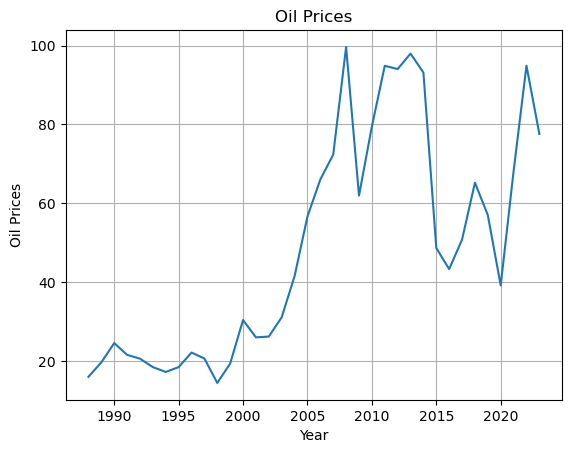

In [125]:
years = [i for i in range(start_year, end_year)]

data_oil_notadjusted = [oil_prices_dict[i] for i in range(start_year, end_year)]

plt.plot(years, data_oil_notadjusted)

plt.xlabel("Year")
plt.ylabel("Oil Prices")
plt.title(f"Oil Prices")
plt.grid(True)
plt.show()




2.431638418079096 60
Average = 2.431638418079096
2.45981981981982 75
Average = 2.45981981981982
2.5025991792065665 86
0 1
Average = 2.4738336713995945
2.482051282051282 105
Average = 2.482051282051282
2.5312407898614797 117
0 1
Average = 2.5097895967270603
2.6606791338582676 128
1.0 2
0 1
Average = 2.615014726212658
2.601138565891473 129
0 1
0 1
0 1
0 1
1.0 2
Average = 2.500347222222222
2.5296174208370794 142
0 1
0 1
0 1
0 1
Average = 2.4603128339648306
2.4648086915446386 146
0 1
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.3520396664412893
2.5267162944582298 156
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
0 1
Average = 2.388895405669599
2.501298701298701 155
0 1
0 1
Average = 2.469435023575151
2.443907675791734 162
0 1
1.0 2
0 1
0 1
Average = 2.382712835199167
2.5376310338334065 179
0 1
Average = 2.523533083645443
2.4966933518969716 170
Average = 2.4966933518969716
2.471192682347351 184
Average = 2.471192682347351
2.47298927188472 178
Average = 2.47298927188472
2.5330838679021146 184
Average = 2.533083867

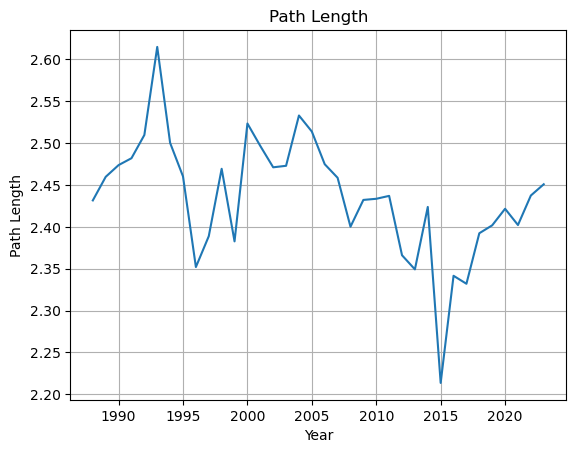

In [126]:
avg_pathlength = {year: safe_avgpathlength(trade_graph_dict[year].to_undirected()) for year in range(start_year, end_year)}

avg_pathlength_data = [avg_pathlength[i] for i in range(start_year, end_year)]

plt.plot(years, avg_pathlength_data)

plt.xlabel("Year")
plt.ylabel("Path Length")
plt.title(f"Path Length")
plt.grid(True)
plt.show()

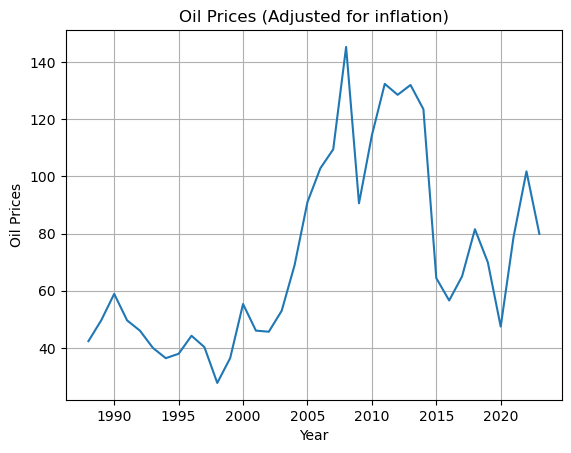

In [128]:
years = [i for i in range(start_year, end_year)]

data_oil = [adjusted_oilprices[i] for i in range(start_year, end_year)]

plt.plot(years, data_oil)

plt.xlabel("Year")
plt.ylabel("Oil Prices")
plt.title(f"Oil Prices (Adjusted for inflation)")
plt.grid(True)
plt.show()

In [135]:
x = oil_prices[(oil_prices['Year'] >= start_year) & (oil_prices['Year'] <= end_year) ].copy()

In [148]:
avg_pathlength_df = pd.DataFrame(list(avg_pathlength.items()), columns=["year", "pathlength"])
avg_pathlength_df

,year,pathlength
0,1988,2.431638
1,1989,2.459820
2,1990,2.473834
3,1991,2.482051
4,1992,2.509790
5,1993,2.615015
6,1994,2.500347
7,1995,2.460313
8,1996,2.352040
9,1997,2.388895


In [151]:
rho = oil_prices['Price'].corr(avg_pathlength_df['pathlength'])
rho

-0.5846589765815476

In [156]:
def diameter_lcc(G):
    if nx.is_connected(G):
        return nx.diameter(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        G_sub = G.subgraph(largest_cc)
        return nx.diameter(G_sub)

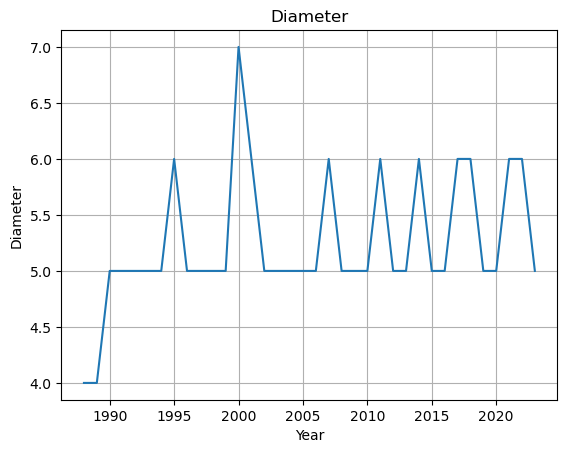

In [157]:
diameter_dict = {year: diameter_lcc(trade_graph_dict[year].to_undirected()) for year in range(start_year, end_year)}

diameter_data = [diameter_dict[i] for i in range(start_year, end_year)]

plt.plot(years, diameter_data)

plt.xlabel("Year")
plt.ylabel("Diameter")
plt.title(f"Diameter")
plt.grid(True)
plt.show()